In [2]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))

In [3]:
from matplotlib import pyplot as plt
import scienceplots

plt.style.use('science')

%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd

from src.tokenizer_utils import load_tokenizer, tokenize

In [4]:
models = [
    ("ai-sage/GigaChat3-10B-A1.8B-base", "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/ai-sage_GigaChat3-10B-A1.8B-base")
]

In [24]:
import pathlib

from tqdm import tqdm

def compute_surprisal(logits, token_ids):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(shifted)
    probs = exp / np.sum(exp, axis=1, keepdims=True)
    token_probs = probs[np.arange(len(token_ids)), token_ids]
    surprisal = -np.log(token_probs)
    return surprisal


stimuli_df = pd.read_csv("../hf_datasets/stimuli.csv")

for model, result_path in models:

    tokenizer = load_tokenizer(model)

    result_dict = {
        "sentence": [],
        "surprisal": [],
        "word_indexes": [],
        "structure": [],
        "target": [],
        "mean_scaled_surprisal": [],
    }

    result_path = pathlib.Path(result_path)
    result_df = pd.read_csv(result_path / "results.csv").merge(stimuli_df[[
        "sentence",
        "target",
        "position",
        "structure",
        "congruent",
    ]], left_on="sentence", right_on="sentence", how="left")

    for i, row in tqdm(result_df.iterrows()):

        logits_relative_path = pathlib.Path(row["logits"])
        logits_absolute_path = result_path.parent.parent / logits_relative_path

        logits = np.load(logits_absolute_path)

        sentence = row["sentence"]
        tokenizer_output = tokenize(
            tokenizer=tokenizer,
            sentences=[sentence],
        )
        input_ids = tokenizer_output["input_ids"]
        per_token_surprisal = compute_surprisal(logits, input_ids)

        word_position = int(row["position"])
        words = sentence.split(" ")
        word = words[word_position]
        word_index = sentence.index(word)

        offset_mappings = tokenizer_output["offset_mapping"][0].tolist()
        offset_mapping_indices = []

        for i, offset_mappings in enumerate(offset_mappings):
            if offset_mappings[0] == offset_mappings[1] and offset_mappings[0] == 0:
                continue
            if offset_mappings[0] >= word_index - 1:
                if word_position == len(words) - 1:
                    offset_mapping_indices.append(i)
                else:
                    next_word = words[word_position + 1]
                    next_word_index = sentence.index(next_word)
                    if offset_mappings[1] <= next_word_index:
                        offset_mapping_indices.append(i)
                    else:
                        break

        # Min max surprisal normalization
        token_ids = input_ids[0].numpy()
        surprisal = compute_surprisal(logits, token_ids)

        # print("Surprisal:", surprisal)

        surprisal_min = np.min(surprisal)
        surprisal_max = np.max(surprisal)

        min_max_scaled_surprisal = surprisal / (surprisal_max - surprisal_min)

        # print(f"Min max scaled surprisal: {min_max_scaled_surprisal}")
        #
        # print("offset_mappings", offset_mapping_indices)

        mean_scaled_surprisal = min_max_scaled_surprisal[max(offset_mapping_indices)].mean()

        # print(f"Mean scaled surprisal: {mean_scaled_surprisal}")


        # print(tokenizer_output)
        #
        # print(offset_mapping_indices)
        # if len(offset_mapping_indices) == 1:
        #     print(tokenizer_output)
        #     print(input_ids[0])
        #     print(offset_mappings)
        #     input_id = input_ids[0][offset_mapping_indices[0]]
        #     print(tokenizer.convert_ids_to_tokens(ids=[input_id], skip_special_tokens=False))
        #     print(tokenizer.decode(
        #         token_ids=[input_id]
        #     ))
        #     print(sentence)
        #     break

        result_dict["sentence"].append(row["sentence"])
        result_dict["surprisal"].append(per_token_surprisal)
        result_dict["target"].append(row["target"])
        result_dict["word_indexes"].append(offset_mapping_indices)
        result_dict["structure"].append(row["structure"])
        result_dict["mean_scaled_surprisal"].append(mean_scaled_surprisal)

    # print(result_dict)

2025-12-18 16:11:25 INFO     src.tokenizer_utils: Tokenizer adds prefix space
600it [00:05, 106.93it/s]


In [25]:
res_df = pd.DataFrame(result_dict)

In [26]:
res_df[["target", "mean_scaled_surprisal"]].to_csv("./target-surp.csv", index=False)

In [11]:
tokenizer = load_tokenizer("ai-sage/GigaChat3-10B-A1.8B-base")

2025-12-09 16:44:08 INFO     src.tokenizer_utils: Tokenizer adds prefix space


In [12]:
result_df = pd.read_csv("../src/results/ai-sage_GigaChat3-10B-A1.8B-base/results.csv")

In [13]:
r = result_df.iloc[0]
r

sentence                        Автобусы проходят массовую дезинфекцией
model                                  ai-sage/GigaChat3-10B-A1.8B-base
instruct                                                          False
hidden_states_path    ./results/ai-sage_GigaChat3-10B-A1.8B-base/000...
logits                ./results/ai-sage_GigaChat3-10B-A1.8B-base/000...
Name: 0, dtype: object

In [14]:
tokens = tokenize(
    tokenizer=tokenizer,
    sentences=[r["sentence"]],
)

In [15]:
token_ids = tokens['input_ids']
token_ids

tensor([[    1, 16553, 40079, 40500, 30876, 38701,   893, 59297,   560,  6637]])

In [18]:


logits = np.load("../src/results/ai-sage_GigaChat3-10B-A1.8B-base/00000_ai-sage_GigaChat3-10B-A1.8B-base.npy_logits.npy")
surp = compute_surprisal(logits, token_ids)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


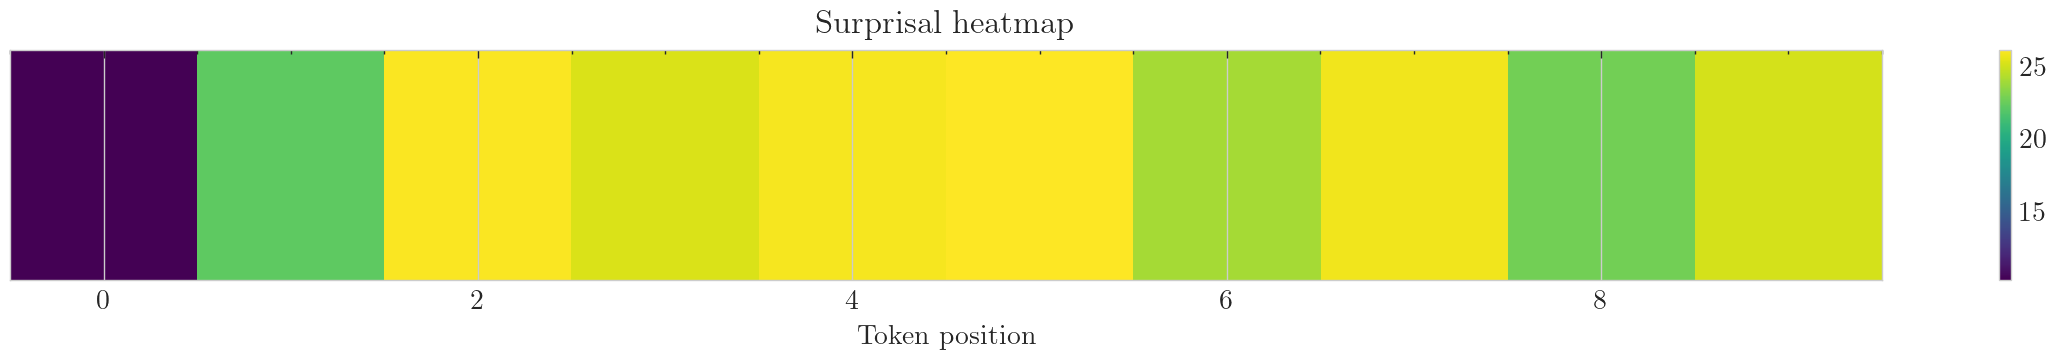

In [19]:


plt.figure(figsize=(12, 2))
plt.imshow(surp, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Surprisal heatmap")
plt.xlabel("Token position")
plt.yticks([])
plt.tight_layout()